In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score

In [34]:
df=pd.read_csv("deepfake_detection_metadata_dataset.csv")
df

,media_id,media_type,content_category,face_count,audio_present,lip_sync_score,visual_artifacts_score,compression_level,lighting_inconsistency_score,source_platform,generation_method,label
0,1,Image,News,2,Yes,0.76,0.24,0.06,0.23,Facebook,NaN,Real
1,2,Video,News,3,Yes,0.01,0.82,0.62,0.98,Instagram,Diffusion,Fake
2,3,Video,Political Speech,3,No,0.20,0.66,0.23,0.77,News Website,GAN,Fake
3,4,Image,Social Media,4,Yes,0.81,0.19,0.68,0.29,YouTube,NaN,Real
4,5,Video,Interview,1,Yes,0.98,0.00,0.23,0.17,Twitter,NaN,Real
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Image,Entertainment,2,Yes,0.86,0.05,0.65,0.09,YouTube,NaN,Real
996,997,Image,Political Speech,2,No,0.74,0.00,0.78,0.28,Instagram,NaN,Real
997,998,Audio,Political Speech,4,Yes,0.55,0.69,0.69,0.48,TikTok,GAN,Fake
998,999,Video,Interview,4,No,0.49,0.47,0.11,0.79,TikTok,Diffusion,Fake


In [35]:
df.head()

,media_id,media_type,content_category,face_count,audio_present,lip_sync_score,visual_artifacts_score,compression_level,lighting_inconsistency_score,source_platform,generation_method,label
0,1,Image,News,2,Yes,0.76,0.24,0.06,0.23,Facebook,NaN,Real
1,2,Video,News,3,Yes,0.01,0.82,0.62,0.98,Instagram,Diffusion,Fake
2,3,Video,Political Speech,3,No,0.20,0.66,0.23,0.77,News Website,GAN,Fake
3,4,Image,Social Media,4,Yes,0.81,0.19,0.68,0.29,YouTube,NaN,Real
4,5,Video,Interview,1,Yes,0.98,0.00,0.23,0.17,Twitter,NaN,Real


In [36]:
df.tail()

,media_id,media_type,content_category,face_count,audio_present,lip_sync_score,visual_artifacts_score,compression_level,lighting_inconsistency_score,source_platform,generation_method,label
995,996,Image,Entertainment,2,Yes,0.86,0.05,0.65,0.09,YouTube,NaN,Real
996,997,Image,Political Speech,2,No,0.74,0.00,0.78,0.28,Instagram,NaN,Real
997,998,Audio,Political Speech,4,Yes,0.55,0.69,0.69,0.48,TikTok,GAN,Fake
998,999,Video,Interview,4,No,0.49,0.47,0.11,0.79,TikTok,Diffusion,Fake
999,1000,Image,Political Speech,2,No,0.18,0.59,0.11,0.72,TikTok,VoiceClone,Fake


In [37]:
df.isnull().sum()

media_id                          0
media_type                        0
content_category                  0
face_count                        0
audio_present                     0
lip_sync_score                    0
visual_artifacts_score            0
compression_level                 0
lighting_inconsistency_score      0
source_platform                   0
generation_method               501
label                             0
dtype: int64

In [38]:
df['generation_method']=df['generation_method'].fillna(df['generation_method'].mode()[0])

In [39]:
df.isnull().sum()

media_id                        0
media_type                      0
content_category                0
face_count                      0
audio_present                   0
lip_sync_score                  0
visual_artifacts_score          0
compression_level               0
lighting_inconsistency_score    0
source_platform                 0
generation_method               0
label                           0
dtype: int64

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   media_id                      1000 non-null   int64  
 1   media_type                    1000 non-null   object 
 2   content_category              1000 non-null   object 
 3   face_count                    1000 non-null   int64  
 4   audio_present                 1000 non-null   object 
 5   lip_sync_score                1000 non-null   float64
 6   visual_artifacts_score        1000 non-null   float64
 7   compression_level             1000 non-null   float64
 8   lighting_inconsistency_score  1000 non-null   float64
 9   source_platform               1000 non-null   object 
 10  generation_method             1000 non-null   object 
 11  label                         1000 non-null   object 
dtypes: float64(4), int64(2), object(6)
memory usage: 93.9+ KB


In [50]:
df.dtypes

media_id                          int64
media_type                       object
content_category                 object
face_count                        int64
audio_present                    object
lip_sync_score                  float64
visual_artifacts_score          float64
compression_level               float64
lighting_inconsistency_score    float64
source_platform                  object
generation_method                object
label                            object
dtype: object

In [52]:
df=pd.get_dummies(df,columns=['media_type','content_category','audio_present','source_platform','generation_method'],drop_first=True)

In [53]:
y=df['label']
x=df.drop(['label'],axis=1)

In [54]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [55]:
model=LogisticRegression()
model.fit(x_train,y_train)

c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [56]:
y_pred=model.predict(x_test)

In [59]:
confusion_matrix(y_test,y_pred)


array([[ 87,   0],
       [  0, 113]])

In [60]:
accuracy_score(y_test,y_pred)

1.0

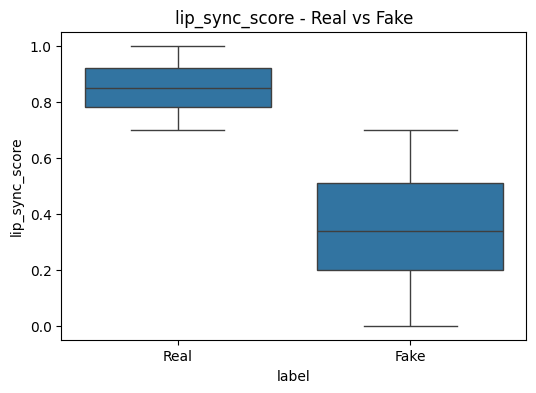

<Figure size 640x480 with 0 Axes>

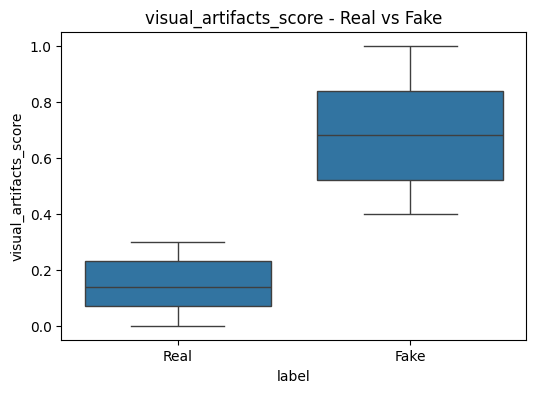

<Figure size 640x480 with 0 Axes>

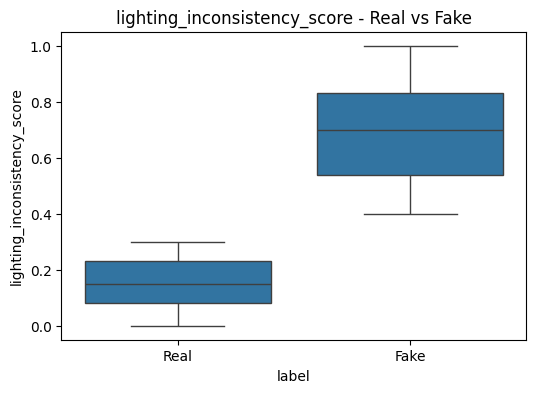

<Figure size 640x480 with 0 Axes>

In [72]:

features = [
    "lip_sync_score",
    "visual_artifacts_score",
    "lighting_inconsistency_score"
]

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="label", y=feature, data=df)
    plt.title(f"{feature} - Real vs Fake")
    plt.show()
    plt.savefig(f"{feature}_boxplot.png")

In [73]:
joblib.dump(model,"deepfake_model.pkl")

['deepfake_model.pkl']